In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [3]:
df = df.drop_duplicates()

In [24]:
df["Date"] = pd.to_datetime(df["Date"])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [26]:
df["Month"] = df["Date"].dt.to_period("M")

In [9]:
def age_group(x):
    if x <= 18:
        return "Teen"
    elif x <= 30:
        return "Young Adult"
    elif x <= 50:
        return "Adult"
    else:
        return "Senior"

df["Age Group"] = df["Age"].apply(age_group)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   int64         
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   int64         
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   period[M]     
 10  Age Group         1000 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(1), period[M](1)
memory usage: 86.1+ KB


In [28]:
df.to_excel("cleaned_data.xlsx", index=False)

In [12]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Product Category"] = le.fit_transform(df["Product Category"])
df["Age Group"] = le.fit_transform(df["Age Group"])

In [14]:
X = df[["Age", "Quantity", "Price per Unit",
        "Gender", "Product Category", "Age Group"]]

y = df["Total Amount"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[1348.3038228    57.59990401  491.88648228  339.08978532 1535.05264547]


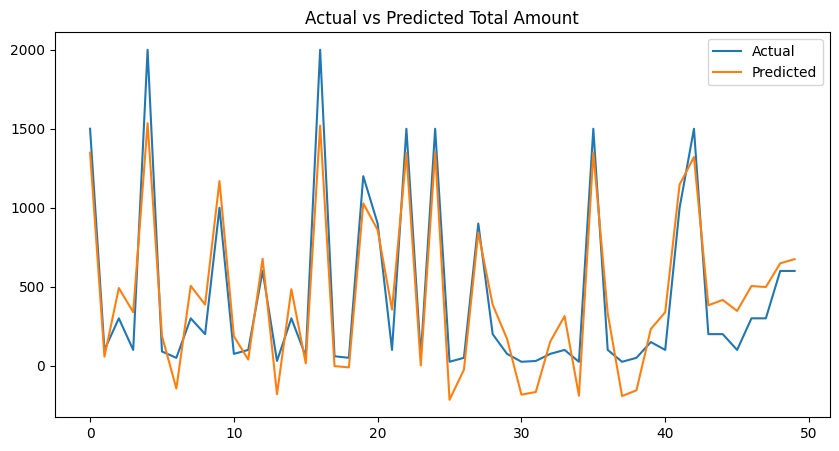

In [19]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Total Amount")

plt.show()

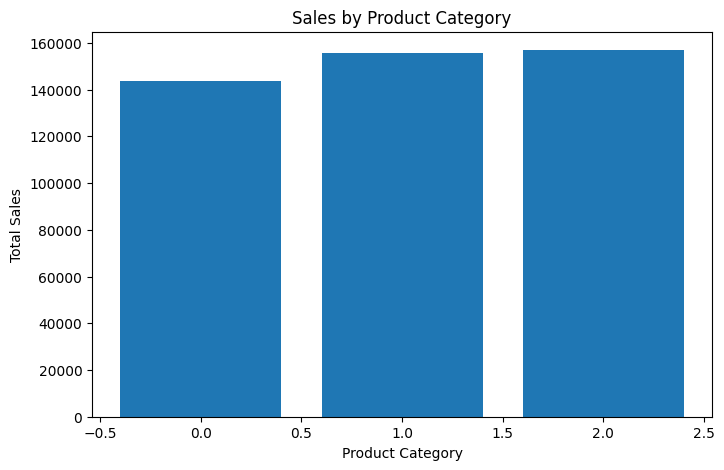

In [20]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(8,5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

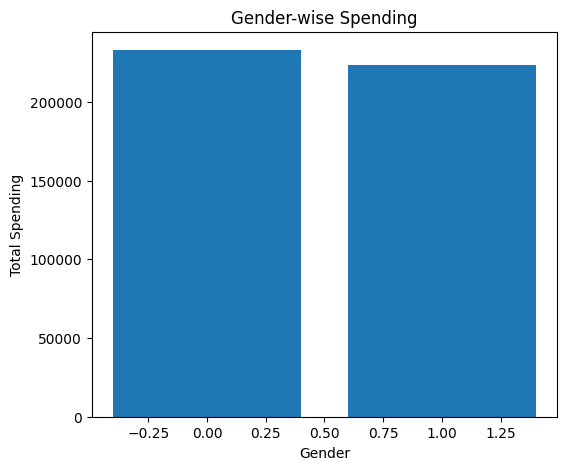

In [21]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

plt.figure(figsize=(6,5))

plt.bar(gender_sales.index, gender_sales.values)

plt.title("Gender-wise Spending")
plt.xlabel("Gender")
plt.ylabel("Total Spending")

plt.show()

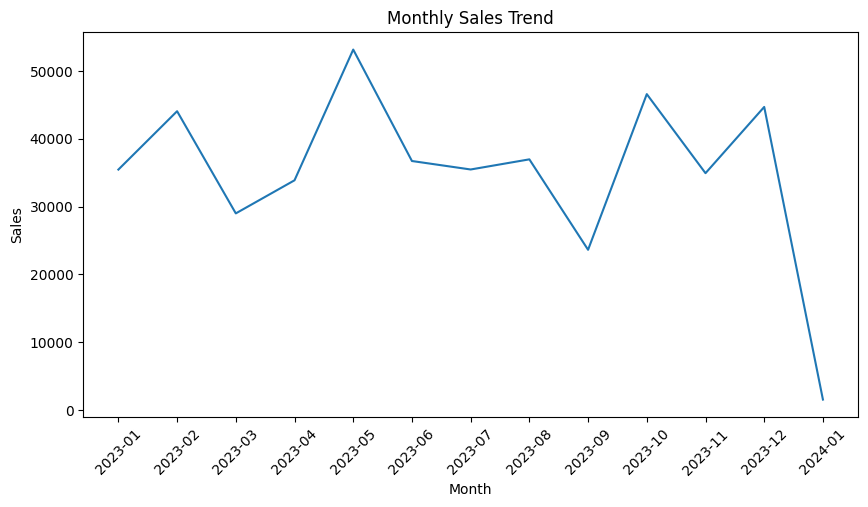

In [22]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index.astype(str),
         monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

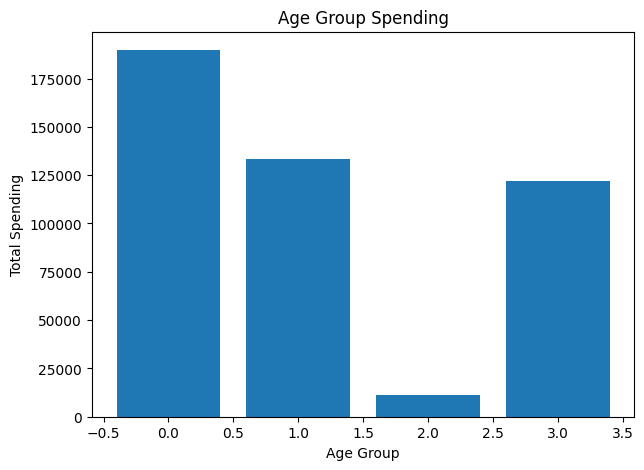

In [23]:
age_sales = df.groupby("Age Group")["Total Amount"].sum()

plt.figure(figsize=(7,5))

plt.bar(age_sales.index, age_sales.values)

plt.title("Age Group Spending")
plt.xlabel("Age Group")
plt.ylabel("Total Spending")

plt.show()